# Positive Emotions Converge in the Mind, but Diverge in the Brain

Consolidated, reproducible notebook for the manuscript's inter-subject
similarity (ISS) work on emotional appraisals.

**Studies 1-2**: positive images/videos are appraised and experienced more
similarly across people than negative ones, and the positive appraisal
space is lower-dimensional.

**Studies 3-4**:
3. Appraisal to emotion PLS transformation -- is the mapping more reliable,
   or does it have different weights, for positive vs. negative images?
4. fMRI ROI inter-subject similarity -- does the behavioral valence effect
   show up in neural pattern similarity across subjects?

Run with the `emo_sim` kernel (Python 3.11, `.miniforge/envs/emo_sim`).
This notebook was rebuilt from `Similarity_Emotion_v8.ipynb` (Studies 1-2),
`Similarity_Emotion_PLS.ipynb`/`PLS_Trans.ipynb` (Study 3), and
`PLS_Emo_App_v3.ipynb` (Study 4) -- the most-developed prior
drafts -- with bug fixes and modern-library compatibility fixes noted
inline where they matter for interpretation.


In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ttest_rel
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics.pairwise import pairwise_distances
from nltools.data import Adjacency
from nltools.stats import two_sample_permutation

PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))  # repo root (this notebook lives in Analysis/)
ANALYSIS_DIR = os.path.join(PROJECT_DIR, "Analysis")
ONLINE_DIR = os.path.join(PROJECT_DIR, "Online")
CK_DIR = os.path.join(ANALYSIS_DIR, "CowenKeltner")
FIGS_DIR = os.path.join(ANALYSIS_DIR, "figs")
os.makedirs(FIGS_DIR, exist_ok=True)


def compute_isc_by_stimulus(wide_df, id_col, feature_cols, min_subjects=2):
    """Fisher-z-averaged inter-subject correlation similarity, per stimulus.

    For each stimulus, computes the pairwise (across-subject) correlation
    similarity of the feature-rating vectors, Fisher z-transforms, averages,
    and transforms back to r. Filters non-finite z-values (from perfectly
    correlated or anti-correlated subject pairs) before averaging -- the
    original notebooks did this inconsistently across sections, which could
    silently corrupt the mean with a stray +-inf.
    """
    isc = {}
    for stim, group in wide_df.groupby(id_col):
        if len(group) < min_subjects:
            continue
        features = group[feature_cols].astype(float)
        sim = Adjacency(1 - pairwise_distances(features, metric="correlation"), matrix_type="similarity")
        z = sim.r_to_z()
        finite = z.data[np.isfinite(z.data)]
        if len(finite) == 0:
            continue
        isc[stim] = np.tanh(np.nanmean(finite))
    return pd.Series(isc, name="Similarity")

## Studies 1-2: Positive Appraisals/Experiences Are More Similar Across People

### Study 1: IAPS images (MTurk, N=201, 136 images)

Appraisal ratings recovered via NNMF from sparse online (MTurk) responses
(`Online/CIAPS_Appraisal_Recovered_NNMF_SGD.csv`). For each image, computes
inter-subject similarity of the 12-dimensional appraisal profile, then
compares positive vs. negative images.


In [2]:
d = pd.read_csv(os.path.join(ONLINE_DIR, "CIAPS_Appraisal_Recovered_NNMF_SGD.csv"))
d_wide = d.pivot(index=["Subject", "Image"], columns="Condition", values="Rating").reset_index()

d_avg = d_wide.groupby("Image").mean(numeric_only=True).reset_index()
d_avg["valence_cat"] = d_avg["Pleasant"].apply(lambda x: "pos" if x > 30 else "neg")
d_wide = d_wide.merge(d_avg[["Image", "valence_cat"]], on="Image", how="left")

appraisal_cols = [c for c in d_wide.columns
                   if c not in ("Subject", "Image", "valence_cat", "Pleasant",
                                "Joy", "Sadness", "Surprise", "Anger", "Fear", "Disgust")]

print(f"N subjects: {d_wide['Subject'].nunique()}, N images: {d_wide['Image'].nunique()}, "
      f"N appraisal dims: {len(appraisal_cols)}")
d_avg["valence_cat"].value_counts()

N subjects: 201, N images: 136, N appraisal dims: 12


valence_cat
neg    68
pos    68
Name: count, dtype: int64

/var/folders/dn/tpf6zggn72zc5z7_ftvn7_9c0000gn/T/ipykernel_81150/640685687.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Neg", "Pos"] if ax.get_xticklabels()[0].get_text() == "neg" else ["Pos", "Neg"])


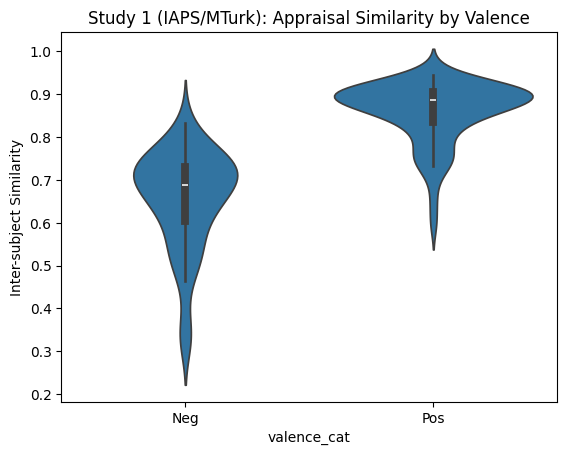

N pos=68, N neg=68
Mean similarity: pos=0.8595, neg=0.6535, diff=0.2059
Two-sample permutation: {'mean': 0.20594054824966213, 'p': 0.0001999600079984003}
(Published Ch.2 headline effect: diff ~= .21)


In [3]:
isc_mturk = compute_isc_by_stimulus(d_wide, "Image", appraisal_cols)
sim_mturk = isc_mturk.reset_index().rename(columns={"index": "Image"})
sim_mturk = sim_mturk.merge(d_avg[["Image", "valence_cat"]], on="Image", how="left")

fig, ax = plt.subplots()
sns.violinplot(x="valence_cat", y="Similarity", data=sim_mturk, ax=ax)
ax.set_ylabel("Inter-subject Similarity")
ax.set_xticklabels(["Neg", "Pos"] if ax.get_xticklabels()[0].get_text() == "neg" else ["Pos", "Neg"])
ax.set_title("Study 1 (IAPS/MTurk): Appraisal Similarity by Valence")
fig.savefig(os.path.join(FIGS_DIR, "IAPS_MTURK_sim_app_valence_barplot_correlation.png"))
plt.show()

pos = sim_mturk.loc[sim_mturk.valence_cat == "pos", "Similarity"]
neg = sim_mturk.loc[sim_mturk.valence_cat == "neg", "Similarity"]
perm = two_sample_permutation(pos.values, neg.values, n_permute=5000)
print(f"N pos={len(pos)}, N neg={len(neg)}")
print(f"Mean similarity: pos={pos.mean():.4f}, neg={neg.mean():.4f}, diff={pos.mean()-neg.mean():.4f}")
print(f"Two-sample permutation: {perm}")
print("(Published Ch.2 headline effect: diff ~= .21)")

#### Appraisal-space complexity by valence

Does it take fewer principal components to explain 90% of the appraisal-rating variance for positive vs. negative images, per subject?

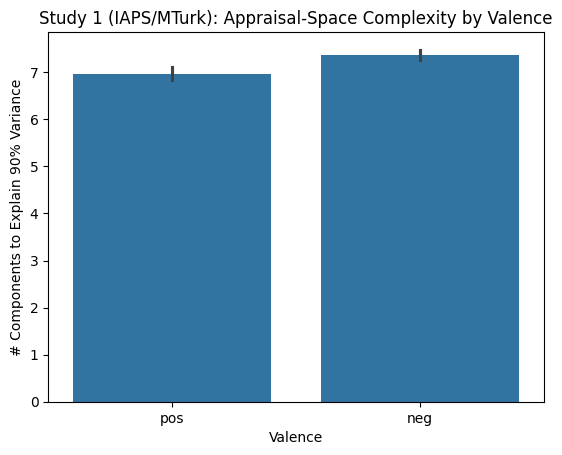

Paired t-test (pos vs neg N components for 90% variance): t=-7.188, p=1.28e-11
Mean N components: pos=6.97, neg=7.37
(Fewer components for positive images = positive appraisal space is lower-dimensional)


In [4]:
pca_records = []
for subid, sub_df in d_wide.groupby("Subject"):
    for valence in ("pos", "neg"):
        sub_valence_df = sub_df.loc[sub_df.valence_cat == valence, appraisal_cols]
        pca = PCA(n_components=0.9)
        pca.fit_transform(sub_valence_df)
        pca_records.append({"Subject": subid, "Valence": valence, "N_comp_90": pca.n_components_})

comp_df = pd.DataFrame(pca_records)

fig, ax = plt.subplots()
sns.barplot(x="Valence", y="N_comp_90", data=comp_df, ax=ax)
ax.set_ylabel("# Components to Explain 90% Variance")
ax.set_title("Study 1 (IAPS/MTurk): Appraisal-Space Complexity by Valence")
fig.savefig(os.path.join(FIGS_DIR, "IAPS_MTURK_PCA_90_Var_App.png"))
plt.show()

pos_n = comp_df.loc[comp_df.Valence == "pos"].set_index("Subject")["N_comp_90"]
neg_n = comp_df.loc[comp_df.Valence == "neg"].set_index("Subject")["N_comp_90"]
pos_n, neg_n = pos_n.align(neg_n, join="inner")
t, p = ttest_rel(pos_n, neg_n)
print(f"Paired t-test (pos vs neg N components for 90% variance): t={t:.3f}, p={p:.4g}")
print(f"Mean N components: pos={pos_n.mean():.2f}, neg={neg_n.mean():.2f}")
print("(Fewer components for positive images = positive appraisal space is lower-dimensional)")

### Study 2: Cowen & Keltner (2017) videos (N stimuli varies by valence split)

Independent replication dataset: 2,185 short videos rated on 13 appraisal
dimensions and 34 emotion categories (Cowen & Keltner, PNAS 2017;
`Analysis/CowenKeltner/`).

In [5]:
avg_dim = pd.read_csv(os.path.join(CK_DIR, "averages_dimensions.csv"))
ind_dim = pd.read_csv(os.path.join(CK_DIR, "indiv_resp_dimensions.csv"))
ind_cat = pd.read_csv(os.path.join(CK_DIR, "indiv_resp_categories.csv"))

avg_dim["valence_cat"] = avg_dim["valence"].apply(lambda x: "pos" if x > 5 else "neg")
print(f"N stimuli: {avg_dim['stimulus_id'].nunique()}")
avg_dim["valence_cat"].value_counts()

N stimuli: 2185


valence_cat
pos    1302
neg     883
Name: count, dtype: int64

#### Dimension-rating similarity

/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)


/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)


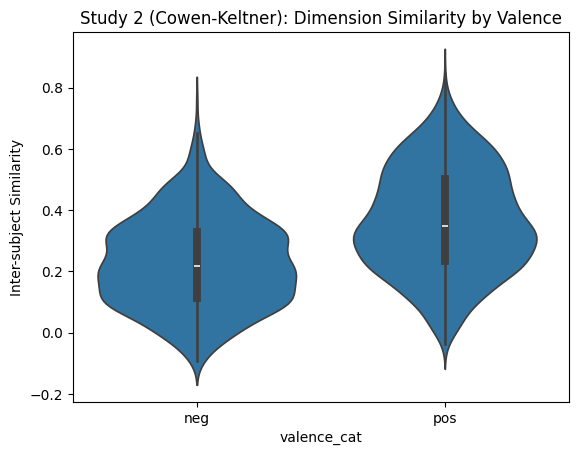

N pos=1302, N neg=883
Mean similarity: pos=0.3642, neg=0.2295, diff=0.1347
Two-sample permutation: {'mean': 0.13474137247374152, 'p': 0.0001999600079984003}


In [6]:
dim_wide = ind_dim.pivot_table(index=["stimulus_id", "subject_id"], columns="dim_name",
                                values="dim_intensity", aggfunc="mean", fill_value=0).reset_index()
dim_feature_cols = [c for c in dim_wide.columns if c not in ("stimulus_id", "subject_id", "valence")]

isc_dim = compute_isc_by_stimulus(dim_wide, "stimulus_id", dim_feature_cols)
sim_dim = isc_dim.reset_index().rename(columns={"index": "stimulus_id"})
sim_dim = sim_dim.merge(avg_dim[["stimulus_id", "valence_cat"]], on="stimulus_id", how="left")

fig, ax = plt.subplots()
sns.violinplot(x="valence_cat", y="Similarity", data=sim_dim, ax=ax)
ax.set_ylabel("Inter-subject Similarity")
ax.set_title("Study 2 (Cowen-Keltner): Dimension Similarity by Valence")
fig.savefig(os.path.join(FIGS_DIR, "CK_App__valence_barplot_correlation.png"))
plt.show()

pos = sim_dim.loc[sim_dim.valence_cat == "pos", "Similarity"]
neg = sim_dim.loc[sim_dim.valence_cat == "neg", "Similarity"]
perm = two_sample_permutation(pos.values, neg.values, n_permute=5000)
print(f"N pos={len(pos)}, N neg={len(neg)}")
print(f"Mean similarity: pos={pos.mean():.4f}, neg={neg.mean():.4f}, diff={pos.mean()-neg.mean():.4f}")
print(f"Two-sample permutation: {perm}")

#### Emotion-category similarity

/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered

/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered

/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered

/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered in arctanh
  return np.arctanh(r)
/Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/.miniforge/envs/emo_sim/lib/python3.11/site-packages/nltools/stats.py:463: RuntimeWarning: divide by zero encountered

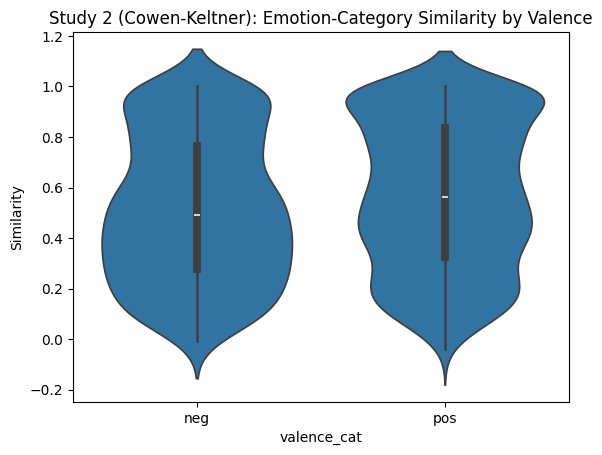

N pos=1302, N neg=883
Mean similarity: pos=0.5694, neg=0.5141, diff=0.0553
Two-sample permutation: {'mean': 0.05527866918513136, 'p': 0.0001999600079984003}


In [7]:
cat_wide = ind_cat.pivot_table(index=["stimulus_id", "subject_id"], columns="cat_name",
                                values="cat_intensity", aggfunc="mean", fill_value=0).reset_index()
cat_feature_cols = [c for c in cat_wide.columns if c not in ("stimulus_id", "subject_id")]

isc_cat = compute_isc_by_stimulus(cat_wide, "stimulus_id", cat_feature_cols)
sim_cat = isc_cat.reset_index().rename(columns={"index": "stimulus_id"})
sim_cat = sim_cat.merge(avg_dim[["stimulus_id", "valence_cat"]], on="stimulus_id", how="left")

fig, ax = plt.subplots()
sns.violinplot(x="valence_cat", y="Similarity", data=sim_cat, ax=ax)
ax.set_ylabel("Similarity")
ax.set_title("Study 2 (Cowen-Keltner): Emotion-Category Similarity by Valence")
fig.savefig(os.path.join(FIGS_DIR, "CK_Emo__valence_barplot_correlation.png"))
plt.show()

pos = sim_cat.loc[sim_cat.valence_cat == "pos", "Similarity"]
neg = sim_cat.loc[sim_cat.valence_cat == "neg", "Similarity"]
perm = two_sample_permutation(pos.values, neg.values, n_permute=5000)
print(f"N pos={len(pos)}, N neg={len(neg)}")
print(f"Mean similarity: pos={pos.mean():.4f}, neg={neg.mean():.4f}, diff={pos.mean()-neg.mean():.4f}")
print(f"Two-sample permutation: {perm}")

## Study 3: Appraisal to Emotion PLS Transformation

For each of 136 IAPS images (fMRI subsample, N=37 rated), fits a PLS
regression mapping 13 appraisal ratings to 6 emotion ratings. Asks whether
the transformation is more reliable (R²) or has different weights for
positive vs. negative images.


In [8]:
FEATURE_NAMES = [
    "Narrative_Rating", "Immoral_Rating", "Pleasant_Rating", "Threatened_Rating",
    "Avoid_Rating", "SociallyAcceptable_Rating", "Interact_Rating",
    "Contamination_Rating", "Suffering_Rating", "Affection_Rating",
    "Desire_Rating", "Astonished_Rating", "Relate_Rating",
]
EMOTIONS = ["Surprise", "Sadness", "Joy", "Fear", "Anger", "Disgust"]
TARGET_NAMES = [f"{e}_Rating" for e in EMOTIONS]

VALENCE_MAP = {
    "AA": "Neg", "AC": "Pos", "AT": "Pos", "CA": "Pos", "CH": "Pos", "CO": "Neg",
    "FA": "Neg", "FO": "Pos", "HC": "Neg", "HM": "Neg", "HV": "Neg", "NC": "Neg",
    "NI": "Neg", "NM": "Neg", "NN": "Neg", "PC": "Pos", "PI": "Pos", "PM": "Pos",
    "PN": "Pos", "SI": "Pos", "SX": "Pos", "TH": "Neg",
}
CATEGORY_MAP = {
    "AA": "Animal_Gory", "AC": "Adult_Organized_Sports", "AT": "Adult_Headshot",
    "CA": "Animal_Cute", "CH": "Child_Cute", "CO": "Dirty", "FA": "Adult_Failure",
    "FO": "Food_Tasty", "HC": "Adult_Infection", "HM": "Adult_Mutilation",
    "HV": "Adult_Violence", "NC": "Nature_Pollution", "NI": "Human_Despair",
    "NM": "Racist_Violence", "NN": "Nature_Grime", "PC": "Landmarks_Pretty",
    "PI": "Human_Connection", "PM": "Helping_People", "PN": "Nature_Pretty",
    "SI": "People_Social", "SX": "Sex", "TH": "Fear_Startle",
}
PLS_FIGS_DIR = os.path.join(ANALYSIS_DIR, "figs", "trans")
os.makedirs(PLS_FIGS_DIR, exist_ok=True)

In [9]:
def normalize_coef(coef, n_features):
    """sklearn<1.1 returns (n_features, n_targets); sklearn>=1.1 returns (n_targets, n_features)."""
    return coef if coef.shape[0] == n_features else coef.T


def run_pls_transformation(ratings_csv):
    d = pd.read_csv(ratings_csv)
    d = d.drop(d.columns[[0]], axis=1)

    records = []
    emotion_coeff_matrices = {e: {} for e in EMOTIONS}
    joint_trans_matrix = {}

    for image, image_df in d.groupby("Image"):
        pls_joint = PLSRegression(n_components=13)
        pls_joint.fit(image_df[FEATURE_NAMES], image_df[TARGET_NAMES])
        coef = normalize_coef(pls_joint.coef_, len(FEATURE_NAMES))  # (13, 6)
        joint_trans_matrix[image] = coef.flatten()

        row = {
            "Image": image,
            "PLS_Coeff": coef.mean(),
            "PLS_R2": pls_joint.score(image_df[FEATURE_NAMES], image_df[TARGET_NAMES]),
        }

        for i, emotion in enumerate(EMOTIONS):
            target = f"{emotion}_Rating"
            pls_emotion = PLSRegression(n_components=13)
            pls_emotion.fit(image_df[FEATURE_NAMES], image_df[target])

            emotion_coeffs = coef[:, i]
            emotion_coeff_matrices[emotion][image] = emotion_coeffs

            row[f"{emotion}_PLS_Coeff"] = emotion_coeffs.mean()
            row[f"{emotion}_PLS_R2"] = pls_emotion.score(image_df[FEATURE_NAMES], image_df[target])

        records.append(row)

    all_images_trans = pd.DataFrame(records)
    prefix = all_images_trans["Image"].str[0:2]
    all_images_trans["Valence"] = prefix.map(VALENCE_MAP)
    all_images_trans["Category"] = prefix.map(CATEGORY_MAP)
    return all_images_trans, joint_trans_matrix, emotion_coeff_matrices


all_images_trans, joint_trans_matrix, emotion_coeff_matrices = run_pls_transformation(
    os.path.join(ANALYSIS_DIR, "IAPS_rating.csv")
)
all_images_trans.head()

,Image,PLS_Coeff,PLS_R2,Surprise_PLS_Coeff,Surprise_PLS_R2,Sadness_PLS_Coeff,Sadness_PLS_R2,Joy_PLS_Coeff,Joy_PLS_R2,Fear_PLS_Coeff,Fear_PLS_R2,Anger_PLS_Coeff,Anger_PLS_R2,Disgust_PLS_Coeff,Disgust_PLS_R2,Valence,Category
0,AA-9181.jpg,-0.023832,0.400191,-0.006814,0.471848,0.035362,0.372638,0.046906,0.412908,-0.185699,0.217136,0.018969,0.536773,-0.051713,0.389845,Neg,Animal_Gory
1,AA-9561.jpg,0.020974,0.405224,0.071580,0.497561,0.033359,0.600788,0.062739,0.373683,0.019167,0.325549,0.018610,0.434434,-0.079609,0.199326,Neg,Animal_Gory
2,AA-A041.jpg,0.047046,0.397262,0.048823,0.514178,0.056154,0.451778,0.109658,0.317581,-0.025683,0.302232,0.052186,0.500249,0.041137,0.297553,Neg,Animal_Gory
3,AA-A069.jpg,0.017355,0.484707,-0.134940,0.718748,0.106051,0.377327,-0.066730,0.381221,0.003912,0.125706,0.085282,0.707294,0.110557,0.597947,Neg,Animal_Gory
4,AA-A095.jpg,-0.006356,0.472337,0.024817,0.604905,-0.097469,0.298280,-0.011593,0.405447,-0.057557,0.345416,0.003064,0.588370,0.100606,0.591606,Neg,Animal_Gory


In [10]:
pos_coeff = all_images_trans.loc[all_images_trans["Valence"] == "Pos", "PLS_Coeff"]
neg_coeff = all_images_trans.loc[all_images_trans["Valence"] == "Neg", "PLS_Coeff"]
pos_r2 = all_images_trans.loc[all_images_trans["Valence"] == "Pos", "PLS_R2"]
neg_r2 = all_images_trans.loc[all_images_trans["Valence"] == "Neg", "PLS_R2"]

coeff_t, coeff_p = ttest_ind(pos_coeff, neg_coeff)
r2_t, r2_p = ttest_ind(pos_r2, neg_r2)
print(f"PLS_Coeff pos (M={pos_coeff.mean():.3f}) vs neg (M={neg_coeff.mean():.3f}): t={coeff_t:.3f}, p={coeff_p:.4g}")
print(f"PLS_R2 pos (M={pos_r2.mean():.3f}) vs neg (M={neg_r2.mean():.3f}) (transformation reliability): t={r2_t:.3f}, p={r2_p:.4g}")

PLS_Coeff pos (M=0.038) vs neg (M=0.026): t=2.119, p=0.0359
PLS_R2 pos (M=0.495) vs neg (M=0.450) (transformation reliability): t=4.375, p=2.417e-05


### Transformation distance matrices, per emotion

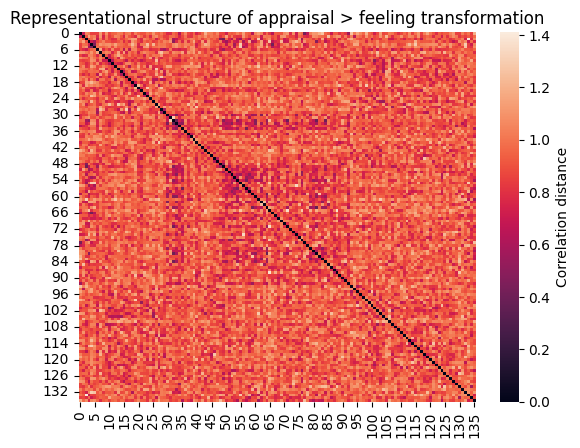

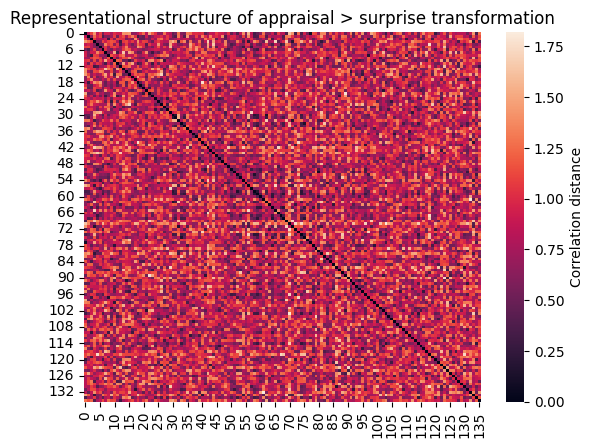

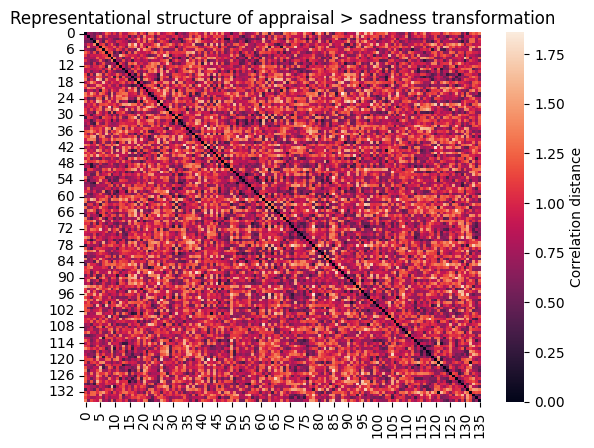

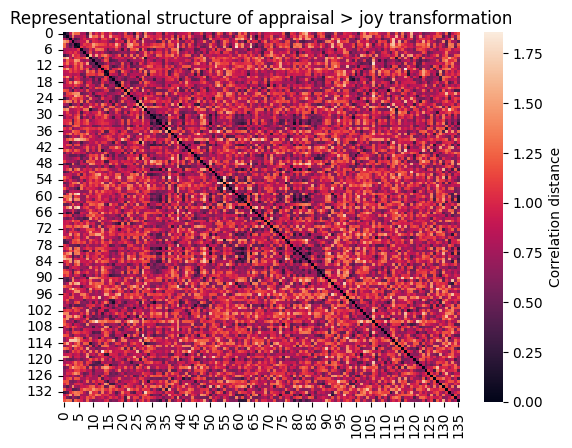

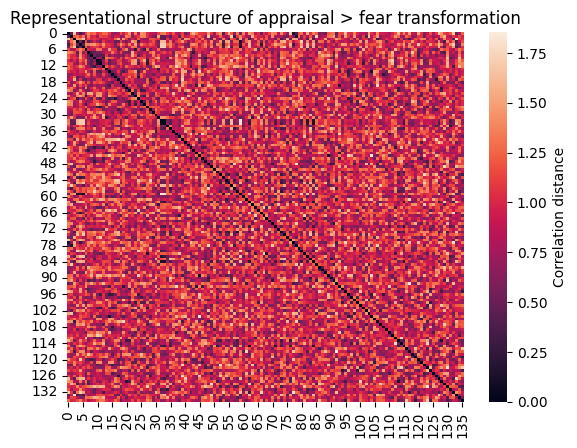

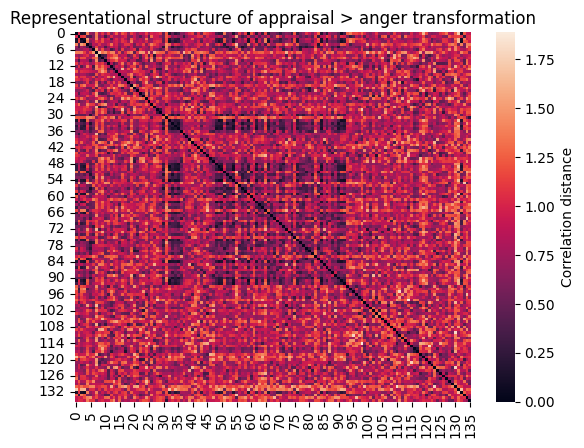

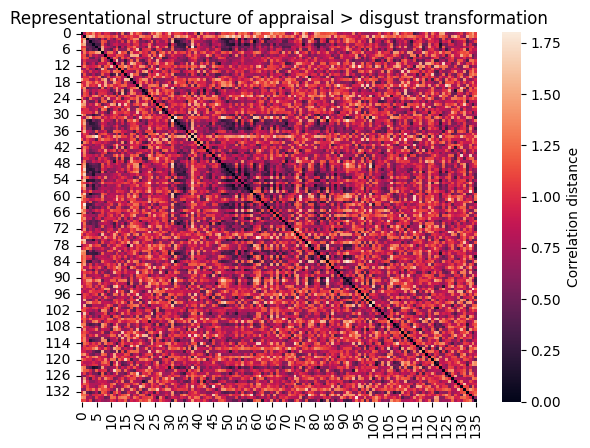

In [11]:
def plot_transformation_heatmaps(joint_trans_matrix, emotion_coeff_matrices, figs_dir):
    joint_df = pd.DataFrame(joint_trans_matrix)
    joint_struc = pairwise_distances(joint_df.T, metric="correlation")
    fig, ax = plt.subplots()
    sns.heatmap(joint_struc, cbar_kws={"label": "Correlation distance"}, ax=ax)
    ax.set_title("Representational structure of appraisal > feeling transformation")
    fig.savefig(os.path.join(figs_dir, "trans_plot.png"))
    plt.show()

    for emotion in EMOTIONS:
        emotion_df = pd.DataFrame(emotion_coeff_matrices[emotion])
        struc = pairwise_distances(emotion_df.T, metric="correlation")
        fig, ax = plt.subplots()
        sns.heatmap(struc, cbar_kws={"label": "Correlation distance"}, ax=ax)
        ax.set_title(f"Representational structure of appraisal > {emotion.lower()} transformation")
        fig.savefig(os.path.join(figs_dir, f"trans_plot_{emotion.lower()}.png"))
        plt.show()


plot_transformation_heatmaps(joint_trans_matrix, emotion_coeff_matrices, PLS_FIGS_DIR)

### Weights and reliability by valence

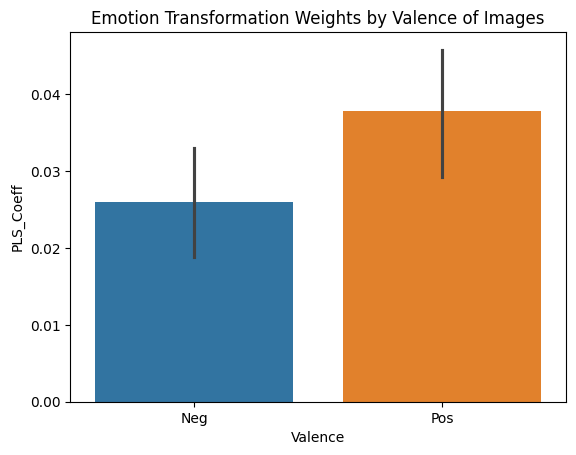

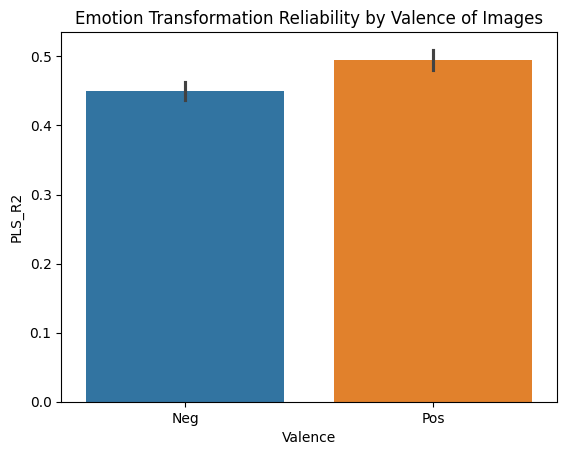

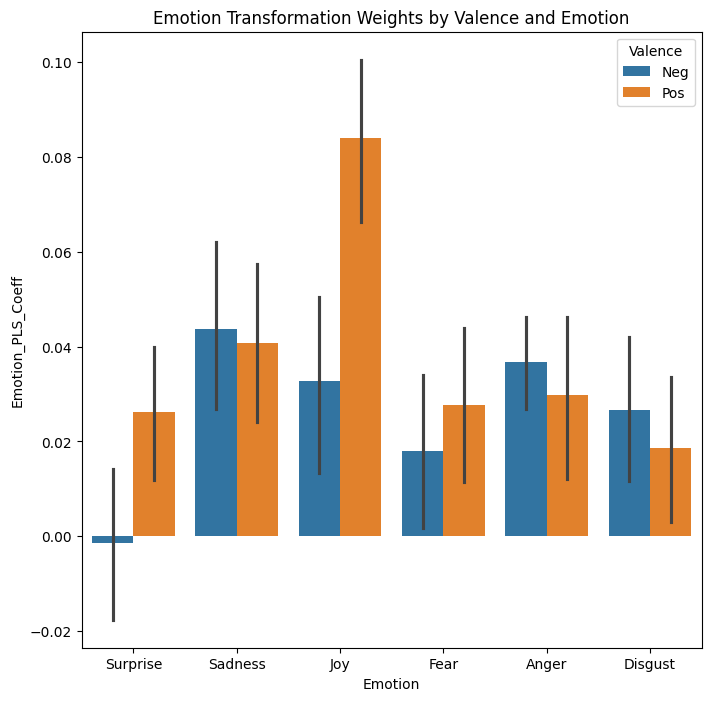

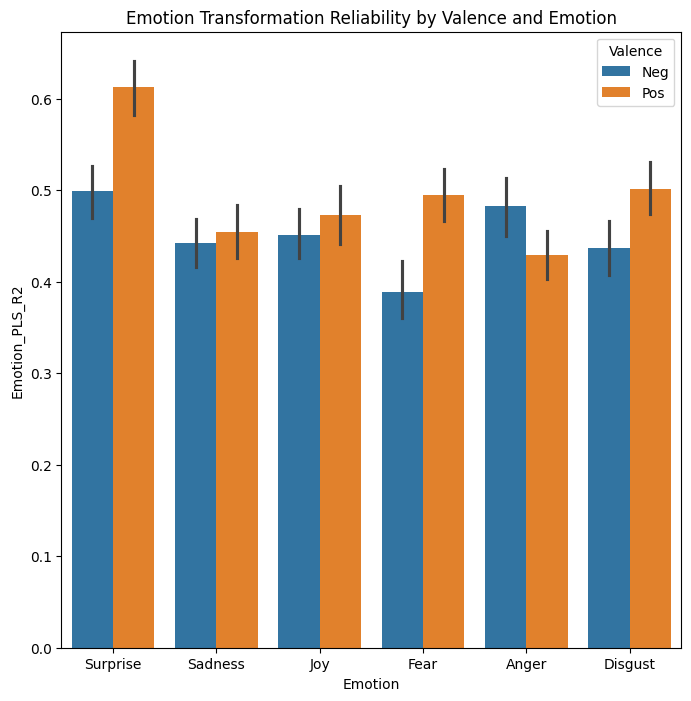

In [12]:
def plot_valence_summaries(all_images_trans, figs_dir):
    fig, ax = plt.subplots()
    sns.barplot(x="Valence", y="PLS_Coeff", hue="Valence", data=all_images_trans, ax=ax, legend=False)
    ax.set_title("Emotion Transformation Weights by Valence of Images")
    fig.savefig(os.path.join(figs_dir, "emo_transformation_barplot_valence.png"))
    plt.show()

    fig, ax = plt.subplots()
    sns.barplot(x="Valence", y="PLS_R2", hue="Valence", data=all_images_trans, ax=ax, legend=False)
    ax.set_title("Emotion Transformation Reliability by Valence of Images")
    fig.savefig(os.path.join(figs_dir, "emo_transformation_R2_barplot_valence.png"))
    plt.show()

    coeff_cols = [f"{e}_PLS_Coeff" for e in EMOTIONS]
    long_coeff = pd.melt(
        all_images_trans, id_vars=["Image", "Valence"], value_vars=coeff_cols,
        var_name="Emotion", value_name="Emotion_PLS_Coeff",
    )
    long_coeff["Emotion"] = long_coeff["Emotion"].str.replace("_PLS_Coeff", "", regex=False)
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.barplot(x="Emotion", y="Emotion_PLS_Coeff", hue="Valence", data=long_coeff, ax=ax)
    ax.set_title("Emotion Transformation Weights by Valence and Emotion")
    fig.savefig(os.path.join(figs_dir, "emo_transformation_barplot_valence_emotion.png"))
    plt.show()

    r2_cols = [f"{e}_PLS_R2" for e in EMOTIONS]
    long_r2 = pd.melt(
        all_images_trans, id_vars=["Image", "Valence"], value_vars=r2_cols,
        var_name="Emotion", value_name="Emotion_PLS_R2",
    )
    long_r2["Emotion"] = long_r2["Emotion"].str.replace("_PLS_R2", "", regex=False)
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.barplot(x="Emotion", y="Emotion_PLS_R2", hue="Valence", data=long_r2, ax=ax)
    ax.set_title("Emotion Transformation Reliability by Valence and Emotion")
    fig.savefig(os.path.join(figs_dir, "emo_transformation_Reliability_barplot_valence_emotion.png"))
    plt.show()

    return long_coeff, long_r2


long_coeff, long_r2 = plot_valence_summaries(all_images_trans, PLS_FIGS_DIR)

In [13]:
out_csv = os.path.join(ANALYSIS_DIR, "PLS_transformation_by_image.csv")
all_images_trans.to_csv(out_csv, index=False)
print(f"Saved {out_csv}")

Saved /Users/daisyburr/Dropbox/IAPS_harddrive/Emo_Similarity/Analysis/PLS_transformation_by_image.csv


## Study 4: fMRI ROI Inter-Subject Similarity

Does the behavioral valence effect (positive emotions appraised more similarly)
show up as higher neural inter-subject similarity (ISS) for positive images?
For each of 136 images, single-trial beta maps from 31 subjects (of 37 in the
fMRI behavioral sample; 6 have no usable beta data -- confirmed against
`fMRI/fmriprep/Missing_Betas.xlsx` and by checking directory coverage
directly) are compared pairwise within each of 50 Neurosynth-parcellation
ROIs, and averaged into a 136 (images) x 50 (ROIs) ISS matrix. Two
permutation tests are run per ROI: one-sample (ISS > 0?) and two-sample
(positive vs. negative images).

Fixes vs. the original (`PLS_Emo_App_v3.ipynb` / `Similarity_Emotion_v8.ipynb`
attempts, neither of which completed):
- `.distance(method='correlation')` -> `.distance(metric='correlation')`
  (this version of nltools does not accept `method=`; it silently fell
  through to sklearn's default 'euclidean', which is almost certainly why
  this analysis never finished/saved in either prior draft)
- v8's draft loaded *all* "pos"-labeled files across *all* subjects and
  images indiscriminately (never actually filtered by the current image) --
  this version globs per-image, per-subject files correctly
- Only the 31 subjects with actual beta directories are used; each has
  complete 136/136 image coverage, so no per-image dropping logic is needed

**This cell reloads the precomputed output** (the full computation --
looping over 136 images x 31 subjects x 50 ROIs -- takes ~26 minutes and was
run once outside this notebook execution). To reproduce from scratch, call
`compute_roi_similarity_matrix(...)` directly instead of loading the CSV.

In [14]:
import glob
import time
from nltools.data import Brain_Data
from nltools.mask import expand_mask
from nltools.stats import fisher_r_to_z, one_sample_permutation, two_sample_permutation

BETA_DIR = os.path.join(PROJECT_DIR, "fMRI", "fmriprep", "fmriprep")
FMRI_FIGS_DIR = os.path.join(ANALYSIS_DIR, "figs", "image_neural_similarity")
os.makedirs(FMRI_FIGS_DIR, exist_ok=True)


def compute_roi_similarity_matrix(images, beta_dir, mask_x):
    """For each image, mean Fisher-z inter-subject correlation similarity per ROI. Returns a 136 x 50 DataFrame."""
    results = {}
    n_rois = len(mask_x)
    for image in images:
        stem = image[:-4]
        files = sorted(glob.glob(os.path.join(beta_dir, "sub-sid*", f"sub-sid*_{stem}.nii.gz")))
        if len(files) < 2:
            continue
        img_dat = Brain_Data(files)
        n = len(files)
        upper_tri_idx = np.triu_indices(n, k=1)
        roi_sims = np.empty(n_rois)
        for i, roi in enumerate(mask_x):
            dist = img_dat.apply_mask(roi).distance(metric="correlation")
            sim_vals = 1 - dist.squareform()[upper_tri_idx]
            roi_sims[i] = sim_vals.mean()
        results[image] = roi_sims
    df = pd.DataFrame(results).T
    df.columns = [f"ROI_{i}" for i in range(n_rois)]
    return df


# NOTE: compute_roi_similarity_matrix() is the function that produced ROI_Image_Similarity.csv,
# run once against the raw fMRI beta maps (~157GB, not distributed in this public repo due to
# human-subjects data governance -- see README). It is included here for methodological
# transparency but is NOT re-executed in this notebook; results below are loaded from the
# precomputed CSV that IS included in the repo (Analysis/figs/image_neural_similarity/).
print("Fetching Neurosynth parcellation...")
mask = Brain_Data("http://neurovault.org/media/images/2099/Neurosynth%20Parcellation_0.nii.gz")
mask_x = expand_mask(mask)
print(f"N ROIs: {len(mask_x)}")

iss_df = pd.read_csv(os.path.join(FMRI_FIGS_DIR, "ROI_Image_Similarity.csv"), index_col=0)
print(f"Loaded precomputed ISS matrix: {iss_df.shape[0]} images x {iss_df.shape[1]} ROIs")
iss_df.head()

Fetching Neurosynth parcellation...


N ROIs: 50
Loaded precomputed ISS matrix: 136 images x 50 ROIs


,ROI_0,ROI_1,ROI_2,ROI_3,ROI_4,ROI_5,ROI_6,ROI_7,ROI_8,ROI_9,...,ROI_40,ROI_41,ROI_42,ROI_43,ROI_44,ROI_45,ROI_46,ROI_47,ROI_48,ROI_49
AA-9181.jpg,0.025437,0.193185,0.039590,0.020264,0.270462,0.065777,0.022505,0.049922,0.026831,0.045545,...,0.032403,0.141677,0.104597,0.146093,0.032618,0.068131,0.107069,0.016406,0.032070,0.086440
AA-9561.jpg,-0.004613,0.199023,0.061521,0.028074,0.279684,0.016738,0.010288,0.021814,0.005235,0.014703,...,0.018309,0.073275,0.105838,0.122339,0.014774,0.016801,0.182499,-0.011877,0.017169,0.030010
AA-A041.jpg,0.118632,0.293985,0.069835,0.066071,0.207527,0.136141,0.117044,0.068995,0.040444,0.118980,...,0.052926,0.115765,0.205473,0.143211,0.039557,0.105420,0.152802,0.060245,0.089197,0.099413
AA-A069.jpg,0.023889,0.213998,0.037540,0.025228,0.228372,0.002799,0.013735,0.060987,0.015108,0.030472,...,0.037820,0.167517,0.105902,0.189864,0.016864,0.033696,0.173791,0.022524,0.019060,0.050231
AA-A095.jpg,0.045859,0.231138,0.030288,0.011554,0.199705,0.105725,0.011249,0.031311,0.004165,0.035996,...,0.023021,0.110639,0.176994,0.165479,0.021423,0.026094,0.129852,0.004067,0.052177,0.058820


ROIs with above-chance ISS (one-sample p<.05): 50 / 50
ROIs with significant pos-vs-neg ISS difference (p<.05): 40 / 50
  Of those: negative > positive in 40, positive > negative in 0
Mean ISS across ROIs (one-sample): [0.0057, 0.2164]


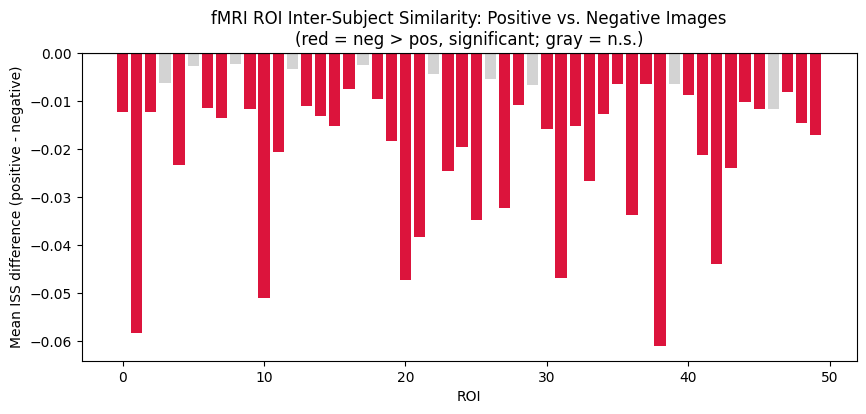

In [15]:
one_sample_df = pd.read_csv(os.path.join(FMRI_FIGS_DIR, "one_sample_perm_by_ROI.csv"))
two_sample_df = pd.read_csv(os.path.join(FMRI_FIGS_DIR, "two_sample_perm_by_ROI.csv"))

n_sig_one = (one_sample_df["p"] < 0.05).sum()
n_sig_two = (two_sample_df["p"] < 0.05).sum()
n_sig_two_neg_higher = ((two_sample_df["p"] < 0.05) & (two_sample_df["mean_diff_pos_minus_neg"] < 0)).sum()
n_sig_two_pos_higher = ((two_sample_df["p"] < 0.05) & (two_sample_df["mean_diff_pos_minus_neg"] > 0)).sum()

print(f"ROIs with above-chance ISS (one-sample p<.05): {n_sig_one} / {len(one_sample_df)}")
print(f"ROIs with significant pos-vs-neg ISS difference (p<.05): {n_sig_two} / {len(two_sample_df)}")
print(f"  Of those: negative > positive in {n_sig_two_neg_higher}, positive > negative in {n_sig_two_pos_higher}")

iss_min = one_sample_df["mean"].min()
iss_max = one_sample_df["mean"].max()
print(f"Mean ISS across ROIs (one-sample): [{iss_min:.4f}, {iss_max:.4f}]")

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["crimson" if (p < 0.05 and d < 0) else ("steelblue" if (p < 0.05 and d > 0) else "lightgray")
          for p, d in zip(two_sample_df["p"], two_sample_df["mean_diff_pos_minus_neg"])]
ax.bar(two_sample_df["ROI"], two_sample_df["mean_diff_pos_minus_neg"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("ROI")
ax.set_ylabel("Mean ISS difference (positive - negative)")
ax.set_title("fMRI ROI Inter-Subject Similarity: Positive vs. Negative Images\n(red = neg > pos, significant; gray = n.s.)")
fig.savefig(os.path.join(FMRI_FIGS_DIR, "roi_pos_vs_neg_summary.png"))
plt.show()

**Result: all 50 ROIs show above-chance neural inter-subject similarity, and
of the 40 ROIs with a significant positive-vs-negative difference, every
single one shows *higher* ISS for negative images -- the opposite direction
from the behavioral appraisal-similarity effect.**
